In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pickle
import torch
import torchio as tio
from sklearn.linear_model import LinearRegression
import scipy.stats


In [19]:
# HELPERS

# Ensures consistent colouring of values even with missing labels
from matplotlib.colors import ListedColormap, BoundaryNorm

# Get the 20 distinct colors from tab20
base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors

# Repeat them to cover 300 labels
n_labels = 300
repeated_colors = np.tile(base_colors, (n_labels // 20 + 1, 1))[:n_labels]

# Create a ListedColormap
cmap = ListedColormap(repeated_colors)

# Optional: Make 0 or NaNs transparent
cmap.set_bad(color=(0, 0, 0, 0))

n_labels = 270
norm = BoundaryNorm(np.arange(n_labels + 1), cmap.N)


def plot_seg(img_arr, size=3, title=""):
    plt.figure(figsize=(size, size))
    plt.imshow(np.ma.masked_where(img_arr == 0, img_arr), cmap=cmap, norm=norm, alpha=1.0, interpolation='nearest')
    plt.title(title)
    plt.show()

/tmp/ipykernel_3114043/2544219101.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors


In [4]:
def load_imgs(folder_path):
    images = []
    file_names = []

    for file_name in os.listdir(folder_path):
        img = sitk.ReadImage(folder_path + file_name)
        img_array = sitk.GetArrayFromImage(img)  # Normalize to [0, 1]

        # NOTE: testing on only the common structures
        #img_array[img_array < 251] = 0

        images.append(img_array)

        file_names.append(file_name)

    # Convert to NumPy array: shape (n_images, height, width)
    images = np.stack(images)
    
    return images, file_names

In [27]:
#folder_path = "../../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/"
folder_path = "../datasets/anat_2d/"

mouse_train_imgs, mouse_train_file_names = load_imgs(folder_path + "mouse_train/")#"train/images/")
mouse_train_imgs_flat = mouse_train_imgs.reshape(len(mouse_train_imgs), -1)
mouse_test_imgs, mouse_test_file_names = load_imgs(folder_path + "mouse_test/")#"test/images/")
mouse_test_imgs_flat = mouse_test_imgs.reshape(len(mouse_test_imgs), -1)

human_train_imgs, human_train_file_names = load_imgs(folder_path + "human_train/")#"train/labels/")
human_train_imgs_flat = human_train_imgs.reshape(len(human_train_imgs), -1)
human_test_imgs, human_test_file_names = load_imgs(folder_path + "human_test/")#"test/labels/")
human_test_imgs_flat = human_test_imgs.reshape(len(human_test_imgs), -1)



In [5]:
print(len(mouse_train_imgs_flat))

660


In [6]:
# combine train and test set to use pca as a dim reduction - not trained
#human_data = np.concatenate((human_train_imgs_flat, human_test_imgs_flat), axis=0)
#mouse_data = np.concatenate((mouse_train_imgs_flat, mouse_test_imgs_flat), axis=0)

In [7]:
import albumentations as A
import numpy as np

elastic_transform = A.ElasticTransform(
    alpha=40, sigma=5, alpha_affine=5, interpolation=1, border_mode=0
)

aug_list = []
for img in mouse_train_imgs:
    for _ in range(100):
        transformed = elastic_transform(image=img)
        aug_list.append(transformed['image'][None, ...])

train_imgs_aug = np.concatenate(aug_list, axis=0)
mouse_train_imgs_aug_flat = train_imgs_aug.reshape(len(train_imgs_aug), -1)


/tmp/ipykernel_3113751/4040064950.py:4: UserWarning: Argument 'alpha_affine' is not valid and will be ignored.
  elastic_transform = A.ElasticTransform(


In [8]:
print(mouse_train_imgs_aug_flat.shape)

(66000, 14400)


In [9]:
# apply forward
num_components = 14000

# 1. z score normalization: zero-mean, unit variance
scaler_mouse = StandardScaler()
mouse_data_scaled = scaler_mouse.fit_transform(mouse_train_imgs_aug_flat)

# scaler_human = StandardScaler()
# human_data_scaled = scaler_human.fit_transform(human_train_imgs_flat)

# 2. apply pca
pca_mouse = PCA(n_components=num_components, svd_solver='randomized')
mouse_data_pca = pca_mouse.fit_transform(mouse_data_scaled)

# pca_human = PCA(n_components=num_components, svd_solver='randomized')
# human_data_pca = pca_human.fit_transform(human_data_scaled)

# with randomized - 1540 imgs and 500 componenets takes 5 min

# back to 2D - on 6600 img with 600 comp -> takes ~25sec :) FAILLLLLLL
# try 5000 comp?? - only 50s
# now wayyyy bigger (66,000 by 14400) for 10,000 componenets - took 10 min

In [14]:
with open("./anat_2d/14000_comp_scaler_mouse.pkl", "wb") as f:
    pickle.dump(scaler_mouse, f)

with open("./anat_2d/14000_comp_pca_mouse.pkl", "wb") as f:
    pickle.dump(pca_mouse, f)

In [29]:
# load pca and scaler
with open('./anat_2d/14000_comp_scaler_human.pkl', 'rb') as f:
    scaler_mouse = pickle.load(f)

with open('./anat_2d/14000_comp_pca_human.pkl', 'rb') as f:
    pca_mouse = pickle.load(f)

In [ ]:
# apply inverse

# mouse_data_recon = pca_mouse.inverse_transform(mouse_data_pca)
# mouse_data_recon_unscale = scaler_mouse.inverse_transform(mouse_data_recon)
# mouse_imgs_recon = np.clip(np.round(mouse_data_recon_unscale.reshape(mouse_data_imgs.shape)), 0, 3) # reshape to 2D imgs

# human_data_recon = pca_human.inverse_transform(human_data_pca)
# human_data_recon_unscale = scaler_human.inverse_transform(human_data_recon)
# human_imgs_recon = np.clip(np.round(human_data_recon_unscale.reshape(human_data_imgs.shape)), 0, 3) # reshape to 2D imgs

In [9]:
print(mouse_test_imgs_flat.shape)


(168, 14400)


In [30]:
# apply to test set
mouse_test_scaled = scaler_mouse.transform(human_test_imgs_flat)
mouse_test_pca = pca_mouse.transform(mouse_test_scaled)
mouse_test_recon = pca_mouse.inverse_transform(mouse_test_pca)
mouse_test_recon_unscale = scaler_mouse.inverse_transform(mouse_test_recon)
mouse_imgs_test_recon = np.clip(np.round(mouse_test_recon_unscale.reshape(human_test_imgs.shape)), 0, 270) # reshape to 2D imgs

# human_test_scaled = scaler_human.transform(human_test_imgs_flat)
# human_test_pca = pca_human.transform(human_test_scaled)
# human_test_recon = pca_human.inverse_transform(human_test_pca)
# human_test_recon_unscale = scaler_human.inverse_transform(human_test_recon)
# human_imgs_test_recon = np.clip(np.round(human_test_recon_unscale.reshape(human_test_imgs.shape)), 0, 3) # reshape to 2D imgs



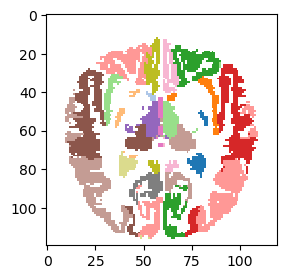

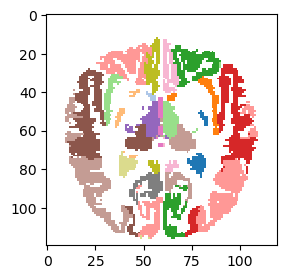

In [31]:
idx = 0
plot_seg(human_test_imgs[idx])
plot_seg(mouse_imgs_test_recon[idx])

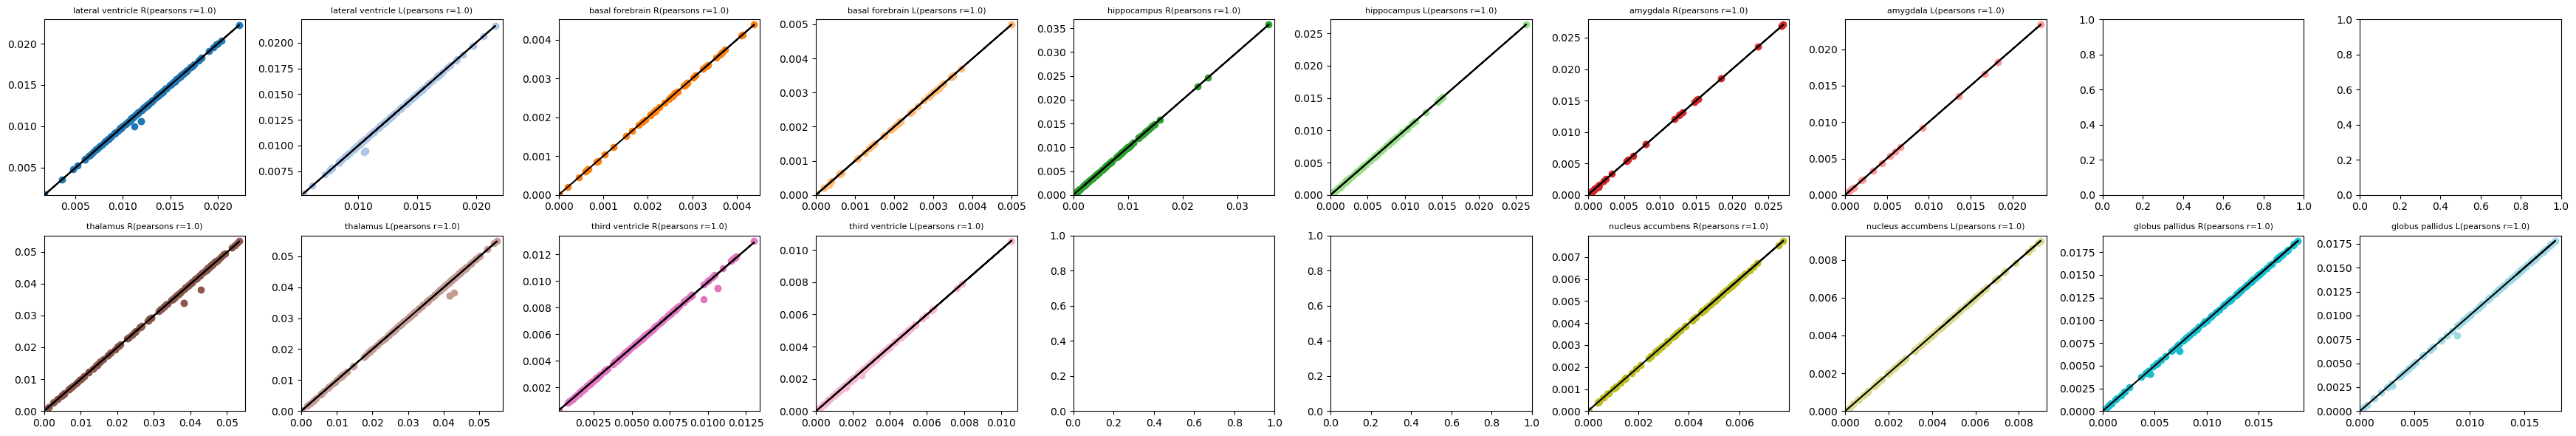

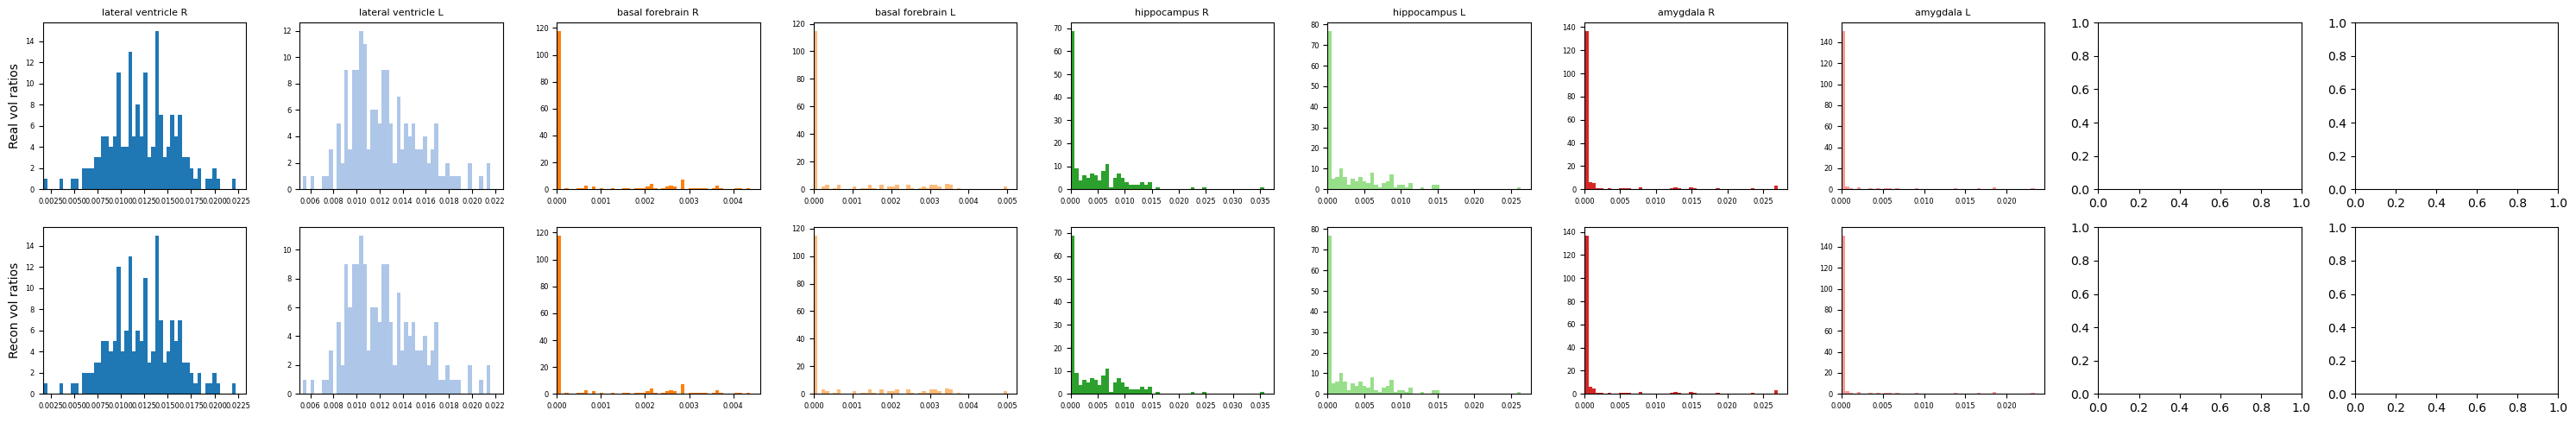

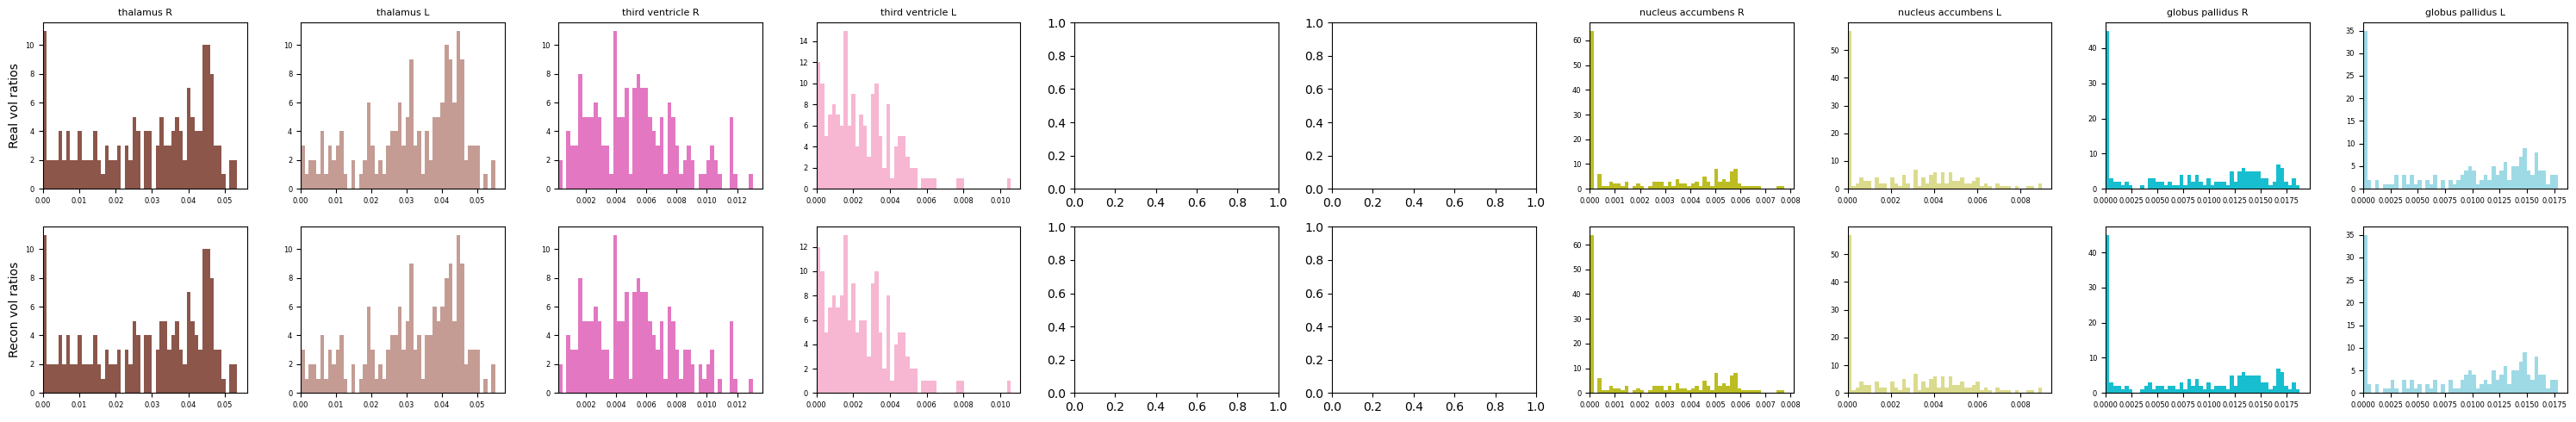

In [32]:
# 3. Plot the volume rato distributions (of common + maybe not commom stucts)

def get_vol_ratio(img_arr):
    vol_ratios = []
    total_count = np.sum(img_arr != 0)

    for i in range(251, 270 + 1):
        vol_ratios.append(0 if total_count == 0 else np.sum(img_arr == i) / total_count)

    return vol_ratios

def compute_common_vol_ratios(imgs):

    vol_ratios = []
    for img_arr in imgs:
        vol_ratios.append(get_vol_ratio(img_arr))

    vol_ratios = np.vstack(vol_ratios)

    return vol_ratios


def plot_vol_ratios(real_vol_ratios, synth_vol_ratios, stuct_names):
    bins = 50

    fig2, axs2 = plt.subplots(2, 10, figsize=(35, 6))

    for plot_index in range(2):  # Two sets: 0–9 and 10–19
        fig, axs = plt.subplots(2, 10, figsize=(30, 5))
        
        for i in range(10):
            struct_i = plot_index * 10 + i
            if struct_i >= len(struct_names):
                break
            color = base_colors[struct_i % len(base_colors)]

            real_data = real_vol_ratios[:, struct_i]
            synth_data = synth_vol_ratios[:, struct_i]
            combined_min = min(np.min(real_data), np.min(synth_data))
            combined_max = max(np.max(real_data), np.max(synth_data))
            if combined_min == combined_max:
                continue

            # analyze matter preservation

            r, p = scipy.stats.pearsonr(real_data, synth_data)

            # # try scaling first???
            # from sklearn.preprocessing import StandardScaler

            # scaler = StandardScaler()
            # arr1_scaled = scaler.fit_transform(real_data.reshape(-1, 1)).flatten()
            # arr2_scaled = scaler.fit_transform(synth_data.reshape(-1, 1)).flatten()

            # r, p = scipy.stats.pearsonr(arr1_scaled, arr2_scaled)

            real_reshape = np.array(real_data).reshape(-1, 1)
            synth_reshape = np.array(synth_data).reshape(-1, 1)
            model = LinearRegression().fit(real_reshape, synth_reshape)

            # Predict y values for the regressed line
            y_pred = model.predict(real_reshape)

            axs2[plot_index, i].scatter(real_data, synth_data, color=color)
            axs2[plot_index, i].plot(real_data, y_pred, color="black")
            axs2[plot_index, i].set_xlim(combined_min*0.97, combined_max*1.03)
            axs2[plot_index, i].set_ylim(combined_min*0.97, combined_max*1.03)
            axs2[plot_index, i].set_title(struct_names[struct_i] + "(pearsons r=" + str(round(r, 2)) + ")", fontsize=8)

            # plot target idx in black
            #axs2[plot_index, i].scatter(real_data[img_idx], synth_data[img_idx], color='black', s=100)


            bin_edges = np.linspace(combined_min, combined_max, bins + 1)
        
            # Real
            axs[0, i].set_xlim(combined_min*0.95, combined_max*1.05)
            axs[0, i].hist(real_vol_ratios[:, struct_i], bins=bin_edges, color=color)
            axs[0, i].set_title(struct_names[struct_i], fontsize=8)
            axs[0, i].tick_params(labelsize=6)

            # Synthetic
            axs[1, i].set_xlim(combined_min*0.95, combined_max*1.05)
            axs[1, i].hist(synth_vol_ratios[:, struct_i], bins=bin_edges, color=color)
            axs[1, i].tick_params(labelsize=6)

        axs[0, 0].set_ylabel("Real vol ratios", fontsize=10)
        axs[1, 0].set_ylabel("Recon vol ratios", fontsize=10)

        fig.tight_layout()
        fig.show()

    fig2.tight_layout()
    fig2.show()

# RUNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN

real_vol_ratios = compute_common_vol_ratios(human_test_imgs)
recon_vol_ratios = compute_common_vol_ratios(mouse_imgs_test_recon)

struct_names = ['lateral ventricle', 'basal forebrain', 'hippocampus', 'amygdala', 'fourth ventricle', 'thalamus', 'third ventricle', 'arbor vita of cerebellum', 'nucleus accumbens', 'globus pallidus']
struct_names = [[struct_name + " R", struct_name + " L"] for struct_name in struct_names]
struct_names = [n for pair in struct_names for n in pair]

plot_vol_ratios(real_vol_ratios, recon_vol_ratios, struct_names)

In [35]:
# apply to train set
mouse_train_scaled = scaler_mouse.transform(human_train_imgs_flat)
mouse_train_pca = pca_mouse.transform(mouse_train_scaled)
mouse_train_recon = pca_mouse.inverse_transform(mouse_train_pca)
mouse_train_recon_unscale = scaler_mouse.inverse_transform(mouse_train_recon)
mouse_imgs_train_recon = np.clip(np.round(mouse_train_recon_unscale.reshape(human_train_imgs.shape)), 0, 270) # reshape to 2D imgs

# #human_train_scaled = scaler_human.transform(human_train_imgs_flat)
# #human_train_pca = pca_human.transform(human_train_scaled)
# human_train_recon = pca_human.inverse_transform(human_data_pca)
# human_train_recon_unscale = scaler_human.inverse_transform(human_train_recon)
# human_imgs_train_recon = np.clip(np.round(human_train_recon_unscale.reshape(human_train_imgs.shape)), 0, 3) # reshape to 2D imgs


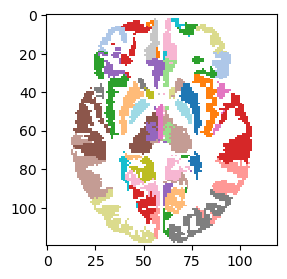

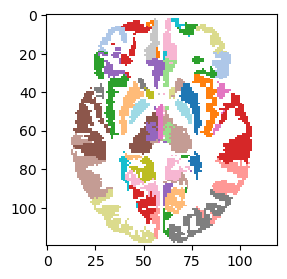

In [36]:
idx = 50
plot_seg(human_train_imgs[idx])
plot_seg(mouse_imgs_train_recon[idx])

In [38]:
encodings = mouse_train_pca
save_path = "./anat_2d/human_train_encodings/"
file_names = human_train_file_names

os.makedirs(save_path, exist_ok=True)

for i, encoding in enumerate(encodings):
    np.save(save_path + file_names[i], encoding)


In [ ]:
err

NameError: name 'err' is not defined

In [ ]:
# train
folder_path = "../datasets/3d_larger/"

human_train_imgs, human_train_file_names = load_imgs(folder_path + "human_train/")#"train/labels/")
human_train_imgs_flat = human_train_imgs.reshape(len(human_train_imgs), -1)


human_train_scaled = scaler_human.transform(human_train_imgs_flat)
human_train_pca = pca_human.transform(human_train_scaled)
human_train_recon = pca_human.inverse_transform(human_train_pca)
human_train_recon_unscale = scaler_human.inverse_transform(human_train_recon)
human_imgs_train_recon = np.clip(np.round(human_train_recon_unscale.reshape(human_train_imgs.shape)), 0, 3) # reshape to 2D imgs


# test
# human_test_imgs, human_test_file_names = load_imgs(folder_path + "human_test/")#"test/labels/")
# human_test_imgs_flat = human_test_imgs.reshape(len(human_test_imgs), -1)

# human_test_scaled = scaler_human.transform(human_test_imgs_flat)
# human_test_pca = pca_human.transform(human_test_scaled)
# human_test_recon = pca_human.inverse_transform(human_test_pca)
# human_test_recon_unscale = scaler_human.inverse_transform(human_test_recon)
# human_imgs_test_recon = np.clip(np.round(human_test_recon_unscale.reshape(human_test_imgs.shape)), 0, 3) # reshape to 2D imgs




SystemError: <built-in function ReadImage> returned a result with an error set

In [ ]:
folder_path = "../datasets/3d_larger/"

mouse_train_imgs, mouse_train_file_names = load_imgs(folder_path + "mouse_train/")#"train/labels/")
#mouse_train_imgs_flat = mouse_train_imgs.reshape(len(mouse_train_imgs), -1)

mouse_test_imgs, mouse_test_file_names = load_imgs(folder_path + "mouse_test/")#"test/labels/")
#mouse_test_imgs_flat = mouse_test_imgs.reshape(len(mouse_test_imgs), -1)

In [ ]:
# BATCH PROCESS INSTEAD (overflows mem)
batch_size = 500


def batch_transform(imgs, scaler, pca, batch_size):
    recon = []
    encode = []

    n = len(imgs)
    for i in range(0, n, batch_size):
        batch = imgs[i:i+batch_size]
        if len(batch) == 0:
            print(i)
            continue
        batch_flat = batch.reshape(len(batch), -1)
        batch_scaled = scaler.transform(batch_flat)
        batch_pca = pca.transform(batch_scaled)
        encode.append(batch_pca)
        batch_recon = pca.inverse_transform(batch_pca)
        batch_unscale = scaler.inverse_transform(batch_recon)
        batch_img = np.clip(np.round(batch_unscale.reshape(imgs[i:i+batch_size].shape)), 0, 3)
        recon.append(batch_img)

    # Combine all batches
    recon = np.concatenate(recon, axis=0)
    encode = np.concatenate(encode, axis=0)

    return encode, recon

mouse_train_encode, mouse_train_recon = batch_transform(mouse_train_imgs, scaler_mouse, pca_mouse, batch_size)
mouse_test_encode, mouse_test_recon = batch_transform(mouse_test_imgs, scaler_mouse, pca_mouse, batch_size)

# takes ~3min

In [ ]:
print(human_train_recon.shape)

(1680, 1843200)


In [ ]:
folder_path = "../datasets/3d_larger/"

mouse_test_scaled = scaler_mouse.transform(mouse_test_imgs_flat)
mouse_test_pca = pca_mouse.transform(mouse_test_scaled)
mouse_test_recon = pca_mouse.inverse_transform(mouse_test_pca)
mouse_test_recon_unscale = scaler_mouse.inverse_transform(mouse_test_recon)
mouse_imgs_test_recon = np.clip(np.round(mouse_test_recon_unscale.reshape(mouse_test_imgs.shape)), 0, 3) # reshape to 2D imgs

mouse_train_scaled = scaler_mouse.transform(mouse_train_imgs_flat)
mouse_train_pca = pca_mouse.transform(mouse_train_scaled)
mouse_train_recon = pca_mouse.inverse_transform(mouse_data_pca)
mouse_train_recon_unscale = scaler_mouse.inverse_transform(mouse_train_recon)
mouse_imgs_train_recon = np.clip(np.round(mouse_train_recon_unscale.reshape(mouse_train_imgs.shape)), 0, 3) # reshape to 2D imgs


NameError: name 'scaler_mouse' is not defined

acc: 96.005
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


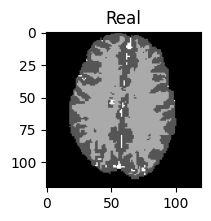

[0. 1. 2. 3.]


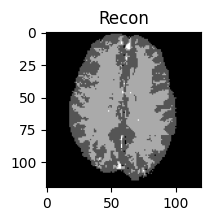

acc: 96.0889
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


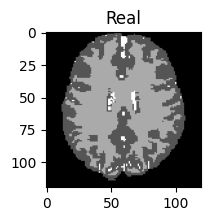

[0. 1. 2. 3.]


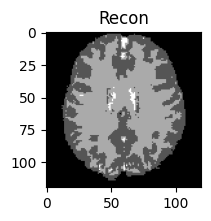

acc: 95.4538
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


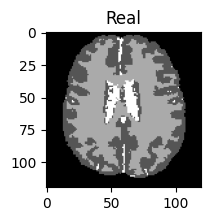

[0. 1. 2. 3.]


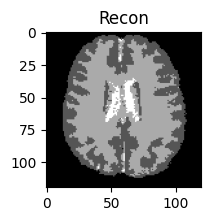

acc: 95.1991
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


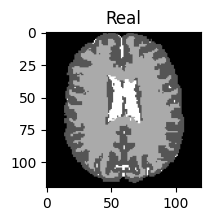

[0. 1. 2. 3.]


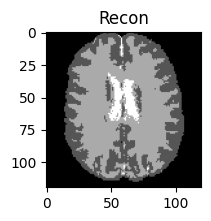

acc: 95.9313
real: [0. 1. 2. 3.]
recon: [0. 1. 2. 3.]
[0. 1. 2. 3.]


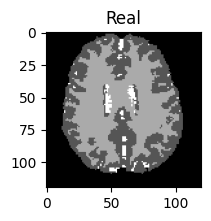

[0. 1. 2. 3.]


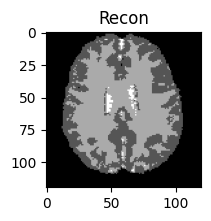

In [ ]:
idxs = [0, 1, 2,  10, 12]
slice_idx = 80

for idx in idxs:
    real = human_train_imgs[idx][slice_idx]
    recon = human_imgs_train_recon[idx][slice_idx]

    print("acc:", np.round(np.mean(human_train_imgs[idx] == human_imgs_train_recon[idx])*100, 4))
    print("real:", np.unique(real))
    print("recon:", np.unique(recon))

    print(np.unique(real))
    plt.figure(figsize=(2,3))
    plt.imshow(real, cmap='gray', vmax=3)
    plt.title("Real")
    plt.show()

    print(np.unique(recon))
    plt.figure(figsize=(2,3))
    plt.imshow(recon, cmap='gray', vmax=3)
    plt.title("Recon")
    plt.show()

# NOTE: whyyy???

In [ ]:
print(len(human_test_file_names))

240


In [ ]:
def save_recons(save_path, imgs, file_names):
    os.makedirs(save_path, exist_ok=True)
    for i, img in enumerate(imgs):
        sitk.WriteImage(sitk.GetImageFromArray(img), save_path + file_names[i])

# save_path = "./3d_larger/pca_mouse_test_500_recon_5_non_lin_aug/"
# save_recons(save_path, mouse_imgs_test_recon, mouse_test_file_names)

# save_path = ".//3d/pca_mouse_test_500_recon_5_non_lin_aug/"
# save_recons(save_path, mouse_imgs_test_recon, mouse_test_file_names)

# save_path = "./3d_larger/pca_mouse_train_500_recon_5_non_lin_aug/"
# save_recons(save_path, mouse_imgs_train_recon, mouse_train_file_names)

# save_path = "./train_on_all/3d/pca_mouse_train_250_recon/"
# save_recons(save_path, mouse_imgs_train_recon, mouse_train_file_names)


def save_encodings(save_path, encodings, file_names):
    os.makedirs(save_path, exist_ok=True)

    for i, encoding in enumerate(encodings):
        np.save(save_path + file_names[i].split(".")[0], encoding)

#save_encodings("./3d_larger/pca_mouse_train_500_recon_5_non_lin_aug_encode/", mouse_data_pca, mouse_train_file_names)
#save_encodings("./3d_larger/pca_mouse_test_500_recon_4_non_lin_aug_encode/", mouse_test_pca, mouse_test_file_names)
save_recons("./3d_larger/final/mouse_train_recon/", mouse_train_recon, mouse_train_file_names)
save_encodings("./3d_larger/final/mouse_train_encode/", mouse_train_encode, mouse_train_file_names)
save_recons("./3d_larger/final/mouse_test_recon/", mouse_test_recon, mouse_test_file_names)
save_encodings("./3d_larger/final/mouse_test_encode/", mouse_test_encode, mouse_test_file_names)

### Augment 3D dataset

In [ ]:
import numpy as np
import torch
import torchio as tio
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt


In [ ]:
data_path = "../../3D-CycleGan-Pytorch-MedImaging/data/test/images/"
data_save_path = "../datasets/3d_larger/mouse_test/"
num_transf = 6
slice_idx = 80

for file_name in os.listdir(data_path):
    img = sitk.ReadImage(data_path + file_name)
    img_arr = sitk.GetArrayFromImage(img)

    sitk.WriteImage(img, data_save_path + file_name)

    # plt.figure(figsize=(2,3))
    # plt.imshow(img_arr[slice_idx], cmap='gray')
    # plt.title("Original")
    # plt.show()

    tensor = torch.from_numpy(img_arr).unsqueeze(0).float()  # shape: (1, D, H, W)
    subject = tio.Subject(mask=tio.LabelMap(tensor=tensor))

    
    transform = tio.Compose([
        tio.RandomAffine(
            scales=(0.98, 1.02),
            degrees=5,
            translation=2,
            image_interpolation='nearest',
            center='image'
        ),
        tio.CropOrPad(img_arr.shape)
    ])

    # Define transform
    elastic = tio.RandomElasticDeformation(
        num_control_points=7,  # grid resolution, higher = more local warping
        max_displacement=5.0,  # max displacement in mm or voxels
        locked_borders=2,      # keep border fixed (avoid artifacts)
        image_interpolation='nearest'  # preserve label integrity
    )

    for i in range(num_transf):
        # transformed = transform(subject)
        # augmented_tensor = transformed['mask'].data.squeeze(0).numpy()  # shape: (D, H, W)
        # img_augmented = sitk.GetImageFromArray(augmented_tensor)
        # sitk.WriteImage(img_augmented, data_save_path + "affine_" + str(i) + "_" + file_name)

        # plt.figure(figsize=(2,3))
        # plt.imshow(augmented_tensor[slice_idx], cmap='gray')
        # plt.title("transf")
        # plt.show()
    
        non_lin_transformed = elastic(subject)
        non_lin_augmented = non_lin_transformed['mask'].data.squeeze(0).numpy()
        img_non_lin_augmented = sitk.GetImageFromArray(non_lin_augmented)
        sitk.WriteImage(img_non_lin_augmented, data_save_path + "non_lin_" + str(i) + "_" + file_name)

        # plt.figure(figsize=(2,3))
        # plt.imshow(non_lin_augmented[slice_idx], cmap='gray')
        # plt.title("Non lin transf")
        # plt.show()
        


SystemError: <built-in function ResampleImageFilter_Execute> returned a result with an error set